### Configure here

In [7]:
# Camelyon16, NSCLC, TCGA_CRC, STANFORD_793
dataset = "Camelyon16"
output_folder = "Paired_t_test"
csv_path = f"/data_64T_3/Raja/MUFASA/1.WSI_Classification/Statistical_Analysis/data/{dataset}_Results.csv"

### Normality test

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
baselines     = ["CLAM", "Histolab", "Trident"]
metrics       = ["macro_auc", "acc", "bacc", "macro_f1"]
metric_labels = ["Macro-AUC", "ACC", "BACC", "Macro-F1"]

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
df_raw = pd.read_csv(csv_path)
for c in ["acc", "bacc", "macro_auc", "macro_f1"]:
    df_raw[c] = pd.to_numeric(df_raw[c].astype(str).str.strip(), errors="coerce")

print(f"Loaded: {df_raw.shape[0]} rows")
print(f"Methods found: {df_raw['method'].unique().tolist()}")
print(f"Models found:  {df_raw['model'].nunique()} unique models\n")

# ─────────────────────────────────────────────
# BUILD DELTA DATAFRAME
# one row per (model, fold, baseline, metric)
# ─────────────────────────────────────────────
mufasa = df_raw[df_raw['method'] == 'MUFASA'].copy()
rows   = []

for b in baselines:
    base   = df_raw[df_raw['method'] == b].copy()
    merged = mufasa.merge(base,
                          on=['Dataset', 'task', 'model', 'run_id'],
                          suffixes=('_mufasa', '_base'))
    for metric in metrics:
        merged[f'd_{metric}'] = (merged[f'{metric}_mufasa']
                               - merged[f'{metric}_base'])

    for _, row in merged.iterrows():
        for metric in metrics:
            rows.append({
                'model':    row['model'],
                'run_id':   row['run_id'],
                'baseline': b,
                'metric':   metric,
                'delta':    row[f'd_{metric}']
            })

delta_long = pd.DataFrame(rows)
print(f"Delta dataframe: {delta_long.shape[0]} rows")
print(f"  {delta_long['model'].nunique()} models × "
      f"{delta_long['run_id'].nunique()} folds × "
      f"{len(baselines)} baselines × {len(metrics)} metrics\n")

# ─────────────────────────────────────────────
# SHAPIRO-WILK NORMALITY TEST
# ─────────────────────────────────────────────
print("=" * 65)
print("SHAPIRO-WILK NORMALITY TEST ON DELTA DISTRIBUTIONS")
print("H0: deltas are normally distributed")
print("p > 0.05 → normal   |   p <= 0.05 → non-normal")
print("=" * 65)

results = []

for metric, label in zip(metrics, metric_labels):
    print(f"\n{label}:")
    print("-" * 55)
    for baseline in baselines:
        vals = delta_long[
            (delta_long['metric']   == metric) &
            (delta_long['baseline'] == baseline)
        ]['delta'].dropna().values

        if len(vals) >= 3:
            stat, p = shapiro(vals)
            normal  = p > 0.05
            verdict = "normal ✓" if normal else "NON-NORMAL ✗"
            print(f"  MUFASA vs {baseline:10s} | "
                  f"n={len(vals):3d} | "
                  f"W={stat:.4f} | "
                  f"p={p:.4f} | {verdict}")
        else:
            stat, p, normal, verdict = np.nan, np.nan, False, "too few samples"
            print(f"  MUFASA vs {baseline:10s} | n={len(vals)} — {verdict}")

        results.append({
            'metric':   metric,
            'label':    label,
            'baseline': baseline,
            'n':        len(vals),
            'W_stat':   round(stat, 4) if not np.isnan(stat) else np.nan,
            'p_value':  round(p,    4) if not np.isnan(p)    else np.nan,
            'normal':   normal,
            'verdict':  verdict
        })

# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────
results_df = pd.DataFrame(results)

print("\n" + "=" * 65)
print("SUMMARY — recommended test based on normality")
print("=" * 65)

for metric, label in zip(metrics, metric_labels):
    subset      = results_df[results_df['metric'] == metric]
    all_normal  = subset['normal'].all()
    any_normal  = subset['normal'].any()
    recommended = "Paired t-test / N&B" if all_normal else "Wilcoxon / Bootstrap"
    print(f"  {label:12s} → all normal: {str(all_normal):5s} "
          f"→ recommended: {recommended}")

# ─────────────────────────────────────────────
# OVERALL RECOMMENDATION
# ─────────────────────────────────────────────
all_normal_overall = results_df['normal'].all()

print("\n" + "=" * 65)
print("OVERALL RECOMMENDATION")
print("=" * 65)
if all_normal_overall:
    print("""  All deltas are normally distributed.
  → Use Nadeau & Bengio corrected t-test (accounts for CV overlap)
  → Or Linear Mixed Effects Model (accounts for model heterogeneity)""")
else:
    print("""  Some deltas are NON-NORMAL.
  → Use Bootstrap CI (no normality assumption)
  → Or Wilcoxon signed-rank test
  → Mixed Effects Model is still valid (robust to mild non-normality)""")

### Confidence Interval Calculation (t-distribution based)

In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import ttest_1samp          # <-- replaces bootstrap_ci
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 12, 'axes.labelsize': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5,
    'axes.facecolor': 'white', 'axes.edgecolor': 'black',
    'axes.grid': False, 'grid.color': 'lightgray', 'grid.linestyle': '--'
})

def preprocess_data(csv_path):
    raw = pd.read_csv(csv_path)
    for c in ["acc", "bacc", "macro_auc", "macro_f1"]:
        raw[c] = raw[c].astype(str).str.strip()
        raw[c] = raw[c].str.replace(r"\.\.+", ".", regex=True)
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    bad_mask = raw[["acc", "bacc", "macro_auc", "macro_f1"]].isna().any(axis=1)
    bad_rows = raw[bad_mask].copy()
    baselines = ["CLAM", "Histolab", "Trident"]
    mufasa = raw[raw.method == "MUFASA"].copy()
    deltas = []
    for b in baselines:
        base = raw[raw.method == b].copy()
        merged = mufasa.merge(base, on=["Dataset", "task", "model", "run_id"],
                              suffixes=("_mufasa", "_base"))
        merged["d_macro_auc"] = merged["macro_auc_mufasa"] - merged["macro_auc_base"]
        out = merged[["Dataset", "task", "model", "run_id", "d_macro_auc"]].copy()
        out.insert(3, "baseline", b)
        deltas.append(out)
    delta_df = pd.concat(deltas, ignore_index=True).sort_values(
        ["Dataset", "model", "baseline", "run_id"])
    return delta_df, bad_rows

# ── CHANGED: t-test instead of bootstrap CI ──────────────────────────────────
def summarize_results(delta_df):
    summary_rows = []
    for (ds, task, model, baseline), g in delta_df.groupby(
            ["Dataset", "task", "model", "baseline"]):
        values = g["d_macro_auc"].dropna().values
        if len(values) > 1:
            t_stat, p_val = ttest_1samp(values, popmean=0)
        else:
            t_stat, p_val = np.nan, np.nan
        summary_rows.append({
            "Dataset":    ds,
            "task":       task,
            "model":      model,
            "baseline":   baseline,
            "metric":     "macro_auc",
            "delta_mean": round(float(np.mean(values)), 4),
            "t_stat":     round(float(t_stat), 4),
            "df":         len(values) - 1,
            "p_value":    round(float(p_val), 4),
            "n_folds":    len(values),
            # mirror ci_low/ci_high names so create_compact_forest_plot still works
            "ci_low":     round(float(np.mean(values) - np.std(values, ddof=1)), 4),
            "ci_high":    round(float(np.mean(values) + np.std(values, ddof=1)), 4),
        })
    return pd.DataFrame(summary_rows).sort_values(
        ["Dataset", "model", "metric", "baseline"])

def assess_significance(summary_df):
    """Flag rows where the paired t-test is significant at p < 0.05."""
    return summary_df[
        (summary_df["metric"] == "macro_auc") &
        (summary_df["p_value"] < 0.05)
    ].copy()
# ─────────────────────────────────────────────────────────────────────────────

def create_compact_forest_plot(summary_df, metric='macro_auc'):
    plot_data = summary_df[summary_df.metric == metric].copy()
    fig, ax = plt.subplots(figsize=(6, 3))
    baseline_colors = {'CLAM': '#1F77B4', 'Histolab': '#FF7F0E', 'Trident': '#2CA02C'}
    unique_models = plot_data['model'].unique()
    bar_width = 0.25
    index = np.arange(len(unique_models))
    for i, baseline in enumerate(plot_data['baseline'].unique()):
        delta_means, ci_lows, ci_highs = [], [], []
        for model in unique_models:
            row = plot_data[(plot_data['baseline'] == baseline) &
                            (plot_data['model'] == model)]
            if not row.empty:
                delta_means.append(row['delta_mean'].values[0])
                ci_lows.append(row['delta_mean'].values[0] - row['ci_low'].values[0])
                ci_highs.append(row['ci_high'].values[0] - row['delta_mean'].values[0])
            else:
                delta_means.append(0); ci_lows.append(0); ci_highs.append(0)
        ax.bar(index + i * bar_width, delta_means, bar_width,
               yerr=[ci_lows, ci_highs], label=baseline,
               color=baseline_colors[baseline], capsize=3, alpha=0.7,
               error_kw={'elinewidth': 0.75, 'capthick': 0.75, 'ecolor': 'black'})
    ax.set_ylabel('ΔMacro-AUC', fontsize=9)
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(unique_models, rotation=45, ha='right', fontsize=9)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.legend(title='Baseline', loc='best', title_fontsize=9, fontsize=8.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.grid(True, linestyle=':', which='major', color='grey',
                  alpha=0.7, linewidth=0.7)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(f'{output_folder}/{dataset}_Ttest_CI.png', dpi=400,
                bbox_inches='tight', pad_inches=0.1)
    plt.show()

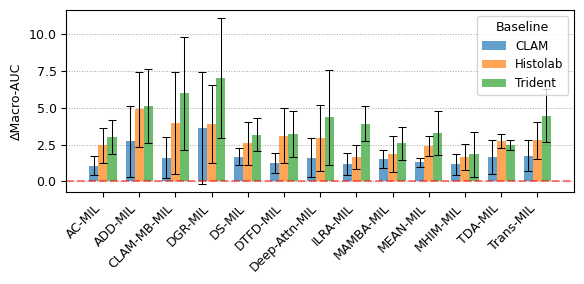


Statistically Significant Improvements (paired t-test, p < 0.05):
       Dataset          model  baseline  delta_mean   t_stat  df  p_value
0   Camelyon16         AC-MIL      CLAM       1.074   3.6924   4   0.0210
1   Camelyon16         AC-MIL  Histolab       2.452   4.6089   4   0.0100
2   Camelyon16         AC-MIL   Trident       3.004   5.8122   4   0.0044
4   Camelyon16        ADD-MIL  Histolab       4.886   4.3289   4   0.0124
5   Camelyon16        ADD-MIL   Trident       5.094   4.5208   4   0.0107
8   Camelyon16    CLAM-MB-MIL   Trident       5.964   3.4922   4   0.0251
10  Camelyon16        DGR-MIL  Histolab       3.912   3.3124   4   0.0296
11  Camelyon16        DGR-MIL   Trident       6.986   3.8569   4   0.0182
12  Camelyon16         DS-MIL      CLAM       1.676   6.5534   4   0.0028
13  Camelyon16         DS-MIL  Histolab       2.588   3.9773   4   0.0164
14  Camelyon16         DS-MIL   Trident       3.152   6.3307   4   0.0032
15  Camelyon16       DTFD-MIL      CLAM      

In [42]:
def main(): 
    delta_df, bad_rows = preprocess_data(csv_path)
    os.makedirs(f"{output_folder}/", exist_ok=True)

    summary_df = summarize_results(delta_df)

    create_compact_forest_plot(summary_df)

    sig_improvements = assess_significance(summary_df)
    print("\nStatistically Significant Improvements (paired t-test, p < 0.05):")
    print(sig_improvements[['Dataset', 'model', 'baseline',
                             'delta_mean', 't_stat', 'df', 'p_value']])

    summary_df.to_csv(f"{output_folder}/{dataset}_Ttest_Full_Summary.csv",
                      index=False, encoding='utf-8-sig')
    sig_improvements.to_csv(f"{output_folder}/{dataset}_Ttest_Significant_Only.csv",
                             index=False, encoding='utf-8-sig')
    print(f"\n✅ Results saved to {output_folder}/")

if __name__ == "__main__":
    main()

### t-test per model based

### Mean and standard deviation for tables in the manuscript and 
### Piared t-test across model

✅ Summary results saved to: Paired_t_test/STANFORD_793_Mean_Std_Results.csv


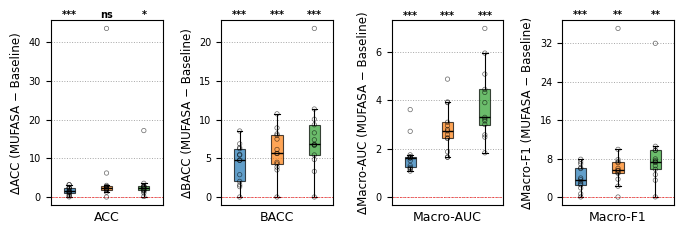

✅ Statistical report saved to: Paired_t_test/STANFORD_793_Ttest_Stats_Report.txt
ONE-SAMPLE PAIRED T-TEST RESULTS

ACC (mean_acc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Mean Δ:  1.6163
    t-stat:  5.7557
    df:      12
    p-value: 9.0819e-05
    Significance: *** (p < 0.001)
  MUFASA vs. Trident:
    Mean Δ:  3.2371
    t-stat:  2.7243
    df:      12
    p-value: 1.8460e-02
    Significance: * (p < 0.05)
  MUFASA vs. Histolab:
    Mean Δ:  5.5374
    t-stat:  1.7327
    df:      12
    p-value: 1.0875e-01
    Significance: ns (p ≥ 0.05)

BACC (mean_bacc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Mean Δ:  4.3209
    t-stat:  6.1350
    df:      12
    p-value: 5.0599e-05
    Significance: *** (p < 0.001)
  MUFASA vs. Trident:
    Mean Δ:  7.8391
    t-stat:  5.5268
    df:      12
    p-value: 1.3053e-04
    Significance: *** (p < 0.001)
  MUFASA vs. Histolab:
    Mean Δ:  5.9006
    t-stat:  7.

In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import ttest_1samp   # <-- changed from wilcoxon
import warnings
warnings.filterwarnings("ignore")

df_raw = pd.read_csv(csv_path)

output_path_csv  = f"{output_folder}/{dataset}_Mean_Std_Results.csv"
stats_file_path  = f"{output_folder}/{dataset}_Ttest_Stats_Report.txt"

df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

# grouped = df_raw.groupby(['model', 'method']).agg({
#     'acc': ['mean', 'std'],
#     'bacc': ['mean', 'std'],
#     'macro_auc': ['mean', 'std'],
#     'macro_f1': ['mean', 'std']
# }).reset_index()

# grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns.values]
# grouped.rename(columns={'model': 'Model', 'method': 'Pre-processor'}, inplace=True)

# for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
#     grouped[f'{m}_mean_std'] = grouped.apply(
#         lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

# df = grouped.rename(columns={
#     'acc_mean': 'mean_acc',
#     'bacc_mean': 'mean_bacc',
#     'macro_auc_mean': 'mean_macro-auc',
#     'macro_f1_mean': 'mean_macro-f1'
# })

# Calculate population mean and population std (ddof=0)
grouped = df_raw.groupby(['model', 'method']).agg({
    'acc': ['mean', lambda x: x.std(ddof=0)],
    'bacc': ['mean', lambda x: x.std(ddof=0)],
    'macro_auc': ['mean', lambda x: x.std(ddof=0)],
    'macro_f1': ['mean', lambda x: x.std(ddof=0)]
}).reset_index()

grouped.columns = ['Model', 'Pre-processor', 
                   'acc_mean', 'acc_std', 
                   'bacc_mean', 'bacc_std', 
                   'macro_auc_mean', 'macro_auc_std', 
                   'macro_f1_mean', 'macro_f1_std'] 

# Note: Ensure these strings match the names assigned above exactly
for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
    grouped[f'{m}_mean_std'] = grouped.apply(lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

# Rename columns for the plotting logic (keep these for your deltas/stats)
df = grouped.rename(columns={
    'acc_mean': 'mean_acc',
    'bacc_mean': 'mean_bacc',
    'macro_auc_mean': 'mean_macro-auc',
    'macro_f1_mean': 'mean_macro-f1'
})

os.makedirs(os.path.dirname(output_path_csv), exist_ok=True)
cols_to_save = ['Model', 'Pre-processor', 'acc_mean_std', 'bacc_mean_std',
                'macro_auc_mean_std', 'macro_f1_mean_std']
df[cols_to_save].to_csv(output_path_csv, index=False, encoding='utf-8-sig')
print(f"✅ Summary results saved to: {output_path_csv}")

metrics       = ["mean_acc", "mean_bacc", "mean_macro-auc", "mean_macro-f1"]
metric_labels = ["ACC", "BACC", "Macro-AUC", "Macro-F1"]

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

all_results = {}

order_keys   = ["MUFASA_vs_CLAM", "MUFASA_vs_Histolab", "MUFASA_vs_Trident"]
order_labels = ["CLAM", "Histolab", "Trident"]

baseline_colors = {
    'CLAM':     '#1F77B4',
    'Histolab': '#FF7F0E',
    'Trident':  '#2CA02C'
}
ordered_colors = [baseline_colors[l] for l in order_labels]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]

    pivot_metric = df.pivot(index="Model", columns="Pre-processor", values=metric)

    delta_metric = pd.DataFrame({
        "MUFASA_vs_CLAM":     pivot_metric["MUFASA"] - pivot_metric["CLAM"],
        "MUFASA_vs_Trident":  pivot_metric["MUFASA"] - pivot_metric["Trident"],
        "MUFASA_vs_Histolab": pivot_metric["MUFASA"] - pivot_metric["Histolab"],
    })

    # --- KEY CHANGE: one-sample t-test instead of Wilcoxon ---
    results = {}
    for col in delta_metric.columns:
        values = delta_metric[col].dropna()
        if len(values) > 1:
            t_stat, p = ttest_1samp(values, popmean=0)  # H0: mean delta = 0
        else:
            t_stat, p = np.nan, np.nan
        results[col] = {
            "mean_delta": np.mean(values),
            "t_stat": t_stat,           # <-- t-statistic (was Wilcoxon W)
            "p_value": p,
            "n": len(values),
            "df": len(values) - 1       # degrees of freedom
        }
    # ---------------------------------------------------------

    all_results[metric] = results

    data_to_plot = [delta_metric[key] for key in order_keys]

    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )

    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, vals in enumerate(data_to_plot, start=1):
        ax.scatter(np.full(len(vals), i), vals,
                   alpha=0.6, s=10, facecolors='none',
                   edgecolors='black', linewidth=0.5, zorder=3)

    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.grid(True, linestyle=':', alpha=0.7, color='grey', linewidth=0.7)
    ax.set_axisbelow(True)

    y_max   = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])

    for i, key in enumerate(order_keys, start=1):
        p_val = results[key]["p_value"]
        if not np.isnan(p_val):
            sig_marker = ("***" if p_val < 0.001 else
                          "**"  if p_val < 0.01  else
                          "*"   if p_val < 0.05  else "ns")
            ax.text(i, y_max + 0.05 * y_range, sig_marker,
                    ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='black')

plt.tight_layout()
os.makedirs(f"{output_folder}/", exist_ok=True)
plt.savefig(f"{output_folder}/{dataset}_Ttest.png", dpi=400,
            bbox_inches='tight', pad_inches=0.1)
plt.show()

# --- Stats report (now reports t, df, mean instead of W, median) ---
caption = """
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across metrics.
One-sample paired t-tests were performed on mean differences (ΔMUFASA − Baseline) across all
MIL models (n = number of model architectures). Each box shows the distribution of performance
differences; individual model results are shown as scatter points. The red dashed line indicates
zero difference. Positive values indicate MUFASA outperforms the baseline.
Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, ns: p ≥ 0.05.
"""

os.makedirs(os.path.dirname(stats_file_path), exist_ok=True)
with open(stats_file_path, "w", encoding="utf-8") as f:
    f.write("="*80 + "\n")
    f.write("ONE-SAMPLE PAIRED T-TEST RESULTS\n")
    f.write("="*80 + "\n")

    for metric, label in zip(metrics, metric_labels):
        f.write(f"\n{label.upper()} ({metric}):\n")
        f.write("-"*60 + "\n")
        for comparison, stats in all_results[metric].items():
            baseline = comparison.split("_vs_")[1]
            f.write(f"  MUFASA vs. {baseline}:\n")
            f.write(f"    Mean Δ:  {stats['mean_delta']:.4f}\n")
            f.write(f"    t-stat:  {stats['t_stat']:.4f}\n")     # key difference
            f.write(f"    df:      {stats['df']}\n")             # n_models - 1
            p_str = f"{stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "N/A"
            f.write(f"    p-value: {p_str}\n")
            if not np.isnan(stats['p_value']):
                p = stats['p_value']
                sig = ("*** (p < 0.001)" if p < 0.001 else
                       "** (p < 0.01)"   if p < 0.01  else
                       "* (p < 0.05)"    if p < 0.05  else
                       "ns (p ≥ 0.05)")
                f.write(f"    Significance: {sig}\n")

    f.write("\n" + "="*80 + "\n")
    f.write("SUGGESTED FIGURE CAPTION:\n")
    f.write("="*80 + "\n")
    f.write(caption + "\n")

print(f"✅ Statistical report saved to: {stats_file_path}")

with open(stats_file_path, "r", encoding="utf-8") as final_report:
    print(final_report.read())

### Paired t-test fold-wise

Summary results saved to: Paired_t_test/Camelyon16_Mean_Std_Results.csv


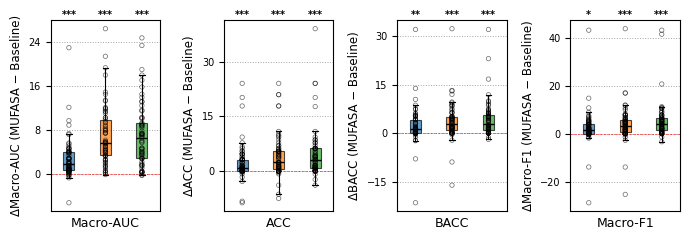

Statistical report saved to: Paired_t_test/Camelyon16_Ttest_Stats_Report.txt
ONE-SAMPLE PAIRED T-TEST RESULTS
Analysis on: raw per-fold deltas

MACRO-AUC (macro_auc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    n (folds x models):  65
    Mean delta:          2.7220
    t-stat:              5.9132
    df:                  64
    p-value:             1.4257e-07
    Significance:        *** (p < 0.001)
  MUFASA vs. Histolab:
    n (folds x models):  65
    Mean delta:          7.0197
    t-stat:              10.5555
    df:                  64
    p-value:             1.2003e-15
    Significance:        *** (p < 0.001)
  MUFASA vs. Trident:
    n (folds x models):  65
    Mean delta:          7.0077
    t-stat:              9.9870
    df:                  64
    p-value:             1.1102e-14
    Significance:        *** (p < 0.001)

ACC (acc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    n (folds x models): 

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import ttest_1samp          # ★ replaced t as t_dist
import warnings
warnings.filterwarnings("ignore")

df_raw = pd.read_csv(csv_path)

output_path_csv = f"{output_folder}/{dataset}_Mean_Std_Results.csv"
stats_file_path = f"{output_folder}/{dataset}_Ttest_Stats_Report.txt"

df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

# ── mean±std table (unchanged) ───────────────
grouped = df_raw.groupby(['model', 'method']).agg({
    'acc':       ['mean', 'std'],
    'bacc':      ['mean', 'std'],
    'macro_auc': ['mean', 'std'],
    'macro_f1':  ['mean', 'std']
}).reset_index()

grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns.values]
grouped.rename(columns={'model': 'Model', 'method': 'Pre-processor'}, inplace=True)

for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
    grouped[f'{m}_mean_std'] = grouped.apply(
        lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

os.makedirs(os.path.dirname(output_path_csv), exist_ok=True)
cols_to_save = ['Model', 'Pre-processor', 'acc_mean_std', 'bacc_mean_std',
                'macro_auc_mean_std', 'macro_f1_mean_std']
grouped[cols_to_save].to_csv(output_path_csv, index=False, encoding='utf-8-sig')
print(f"Summary results saved to: {output_path_csv}")

# ─────────────────────────────────────────────
# ★ PAIRED T-TEST — replaces corrected_resampled_ttest
# one-sample t-test on per-fold deltas vs 0
# ─────────────────────────────────────────────
def paired_ttest(values):
    n = len(values)
    if n > 1:
        t_stat, p_val = ttest_1samp(values, popmean=0)
        return float(t_stat), float(p_val)
    return np.nan, np.nan

# ─────────────────────────────────────────────
metrics       = ["macro_auc", "acc", "bacc", "macro_f1"]
metric_labels = ["Macro-AUC", "ACC", "BACC", "Macro-F1"]

order_keys   = ["MUFASA_vs_CLAM", "MUFASA_vs_Histolab", "MUFASA_vs_Trident"]
order_labels = ["CLAM", "Histolab", "Trident"]

baseline_colors = {
    'CLAM':     '#1F77B4',
    'Histolab': '#FF7F0E',
    'Trident':  '#2CA02C'
}
ordered_colors = [baseline_colors[l] for l in order_labels]

all_results = {}

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]

    # pivot keeping run_id — one row per (model, fold)
    pivot_raw = df_raw.pivot_table(
        index=["model", "run_id"],
        columns="method",
        values=metric
    ).reset_index()

    # delta per fold per model
    delta_df = pd.DataFrame({
        "MUFASA_vs_CLAM":     pivot_raw["MUFASA"] - pivot_raw["CLAM"],
        "MUFASA_vs_Histolab": pivot_raw["MUFASA"] - pivot_raw["Histolab"],
        "MUFASA_vs_Trident":  pivot_raw["MUFASA"] - pivot_raw["Trident"],
    })

    # ★ paired t-test on raw fold deltas
    results = {}
    for col in order_keys:
        values = delta_df[col].dropna().values
        t_stat, p = paired_ttest(values)     # ★ was corrected_resampled_ttest
        results[col] = {
            "mean_delta": float(np.mean(values)),
            "t_stat":     t_stat,
            "p_value":    p,
            "n":          len(values),
            "df":         len(values) - 1
        }

    all_results[metric] = results

    data_to_plot = [delta_df[key].dropna() for key in order_keys]

    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )

    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, vals in enumerate(data_to_plot, start=1):
        ax.scatter(np.full(len(vals), i), vals,
                   alpha=0.6, s=10, facecolors='none',
                   edgecolors='black', linewidth=0.5, zorder=3)

    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.grid(True, linestyle=':', alpha=0.7, color='grey', linewidth=0.7)
    ax.set_axisbelow(True)

    y_max   = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])

    for i, key in enumerate(order_keys, start=1):
        p_val = results[key]["p_value"]
        if not np.isnan(p_val):
            sig_marker = ("***" if p_val < 0.001 else
                          "**"  if p_val < 0.01  else
                          "*"   if p_val < 0.05  else "ns")
            ax.text(i, y_max + 0.05 * y_range, sig_marker,
                    ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='black')

plt.tight_layout()
os.makedirs(output_folder, exist_ok=True)
plt.savefig(f"{output_folder}/{dataset}_PairedTtest.png",   # ★ renamed
            dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()

# ─────────────────────────────────────────────
# STATS REPORT
# ─────────────────────────────────────────────
caption = """
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across metrics.
One-sample paired t-tests were performed on per-fold differences (ΔMUFASA − Baseline)
across all MIL models and folds (n = n_models × k_folds). Each box shows the distribution
of per-fold performance differences; individual fold results are shown as scatter points.
The red dashed line indicates zero difference. Positive values indicate MUFASA outperforms
the baseline. Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, ns: p >= 0.05.
"""

os.makedirs(os.path.dirname(stats_file_path), exist_ok=True)
with open(stats_file_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("ONE-SAMPLE PAIRED T-TEST RESULTS\n")        # ★ updated header
    f.write("Analysis on: raw per-fold deltas\n")
    f.write("=" * 80 + "\n")

    for metric, label in zip(metrics, metric_labels):
        f.write(f"\n{label.upper()} ({metric}):\n")
        f.write("-" * 60 + "\n")
        for comparison, stats in all_results[metric].items():
            baseline = comparison.split("_vs_")[1]
            f.write(f"  MUFASA vs. {baseline}:\n")
            f.write(f"    n (folds x models):  {stats['n']}\n")
            f.write(f"    Mean delta:          {stats['mean_delta']:.4f}\n")
            f.write(f"    t-stat:              {stats['t_stat']:.4f}\n")   # ★ removed 'corrected'
            f.write(f"    df:                  {stats['df']}\n")
            p_str = f"{stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "N/A"
            f.write(f"    p-value:             {p_str}\n")
            if not np.isnan(stats['p_value']):
                p   = stats['p_value']
                sig = ("*** (p < 0.001)" if p < 0.001 else
                       "** (p < 0.01)"   if p < 0.01  else
                       "* (p < 0.05)"    if p < 0.05  else
                       "ns (p >= 0.05)")
                f.write(f"    Significance:        {sig}\n")

    f.write("\n" + "=" * 80 + "\n")
    f.write("SUGGESTED FIGURE CAPTION:\n")
    f.write("=" * 80 + "\n")
    f.write(caption + "\n")

print(f"Statistical report saved to: {stats_file_path}")
with open(stats_file_path, "r", encoding="utf-8") as final_report:
    print(final_report.read())